# Supply Chain Analytics & Inventory Optimization

### Exploratory data analysis

objective: analyze demand, inventory, supplier, warehouse, and financial performance to uncover operational patterns and identify opportunities for inventory optimization.

**Questions aimed to answer:**

- How does demand change over time?
- Which products generate the highest revenue and profit?
- How is inventory distributed across warehouses?
- How do suppliers differ in lead times?
- Do promotions influence demand?
- What operational insights support inventory optimization?


In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 

In [2]:
df= pd.read_csv(r"C:\Users\Pavni Rastogi\Desktop\supply-chain-analytics-project\data used\processed_supply_chain.csv")

In [3]:
df.head()

,date,sku_id,warehouse_id,supplier_id,region,units_sold,inventory_level,supplier_lead_time_days,reorder_point,order_quantity,...,inventory_value,reorder_needed,inventory_difference,year,month,month_name,quarter,day,day_of_week,day_name
0,2024-01-01,SKU_1,WH_1,SUP_8,West,10,592,14,379,0,...,8258.40,0,213,2024,1,January,1,1,0,Monday
1,2024-01-02,SKU_1,WH_1,SUP_8,West,17,575,14,379,0,...,8021.25,0,196,2024,1,January,1,2,1,Tuesday
2,2024-01-03,SKU_1,WH_1,SUP_8,North,35,540,14,379,0,...,7533.00,0,161,2024,1,January,1,3,2,Wednesday
3,2024-01-04,SKU_1,WH_1,SUP_8,South,24,516,14,379,0,...,7198.20,0,137,2024,1,January,1,4,3,Thursday
4,2024-01-05,SKU_1,WH_1,SUP_8,West,21,495,14,379,0,...,6905.25,0,116,2024,1,January,1,5,4,Friday


#

### Demand, Sales & Revenue analysis

In [16]:
#sales over time:

daily_sales = df.groupby('date')[['units_sold', 'revenue']].sum()
daily_sales=daily_sales.reset_index()
daily_sales.head(3)


,date,units_sold,revenue
0,2024-01-01,5054,93009.93
1,2024-01-02,5072,92942.73
2,2024-01-03,5278,96500.72


In [99]:
#defining functions for axis value formatting
def millions_formatter(x, pos):
    return f"{x*1e-6:.1f}M"

def thousands_formatter(x, pos):
    return f"{x*1e-3:.0f}K"

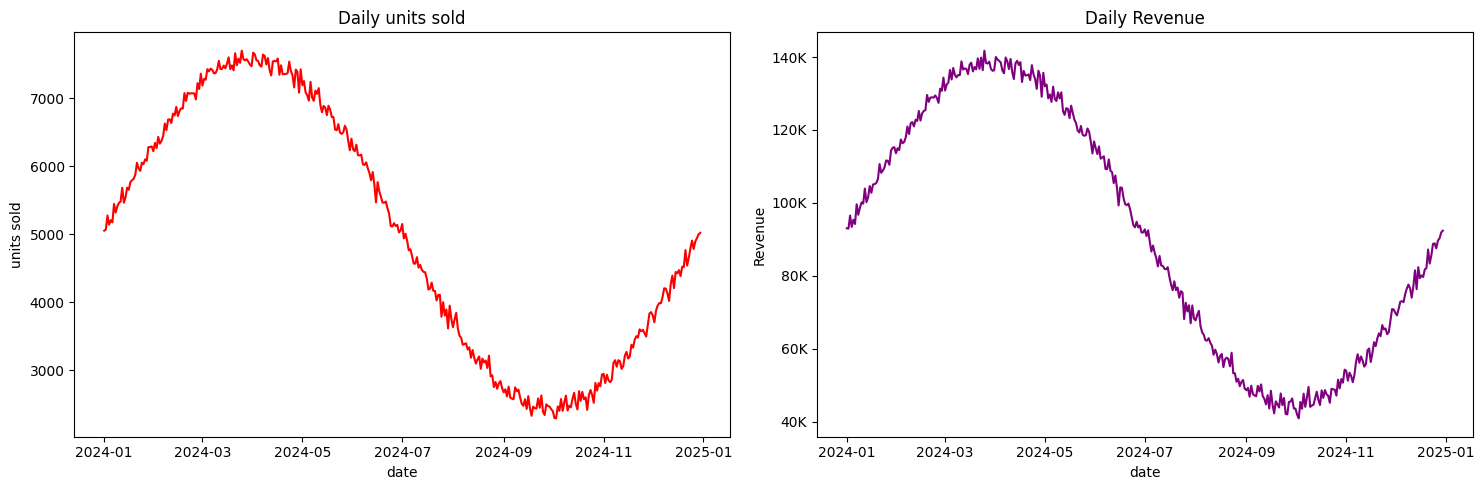

In [92]:
#plotting daily sales & daily revenue:
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

daily_sales['date'] = pd.to_datetime(daily_sales['date'])
fig, axes= plt.subplots(1,2, figsize=(15,5))
sns.lineplot(x='date', y='units_sold', data=daily_sales, ax=axes[0], color='red')
axes[0].set_title('Daily units sold')
axes[0].set_ylabel('units sold')

sns.lineplot(x='date', y='revenue', data= daily_sales, ax=axes[1],color='purple')
axes[1].set_title('Daily Revenue')
axes[1].set_ylabel('Revenue')
axes[1].yaxis.set_major_formatter(FuncFormatter(thousands_formatter))

plt.tight_layout()
plt.show()

- clear seasonal pattern in daily units sold & daily revenue.

In [84]:
#monthly sales & revenue:
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
monthly_sales = df.groupby('month_name')[['units_sold', 'revenue', 'profit']].sum().reset_index()
monthly_sales['month_name']= pd.Categorical(monthly_sales['month_name'], categories=month_order, ordered=True)
monthly_sales= monthly_sales.sort_values('month_name').reset_index(drop=True)
monthly_sales.head(3)

,month_name,units_sold,revenue,profit
0,January,176681,"3,224,684.78","1,071,043.99"
1,February,197188,"3,596,623.24","1,192,850.66"
2,March,231596,"4,232,663.58","1,403,172.35"


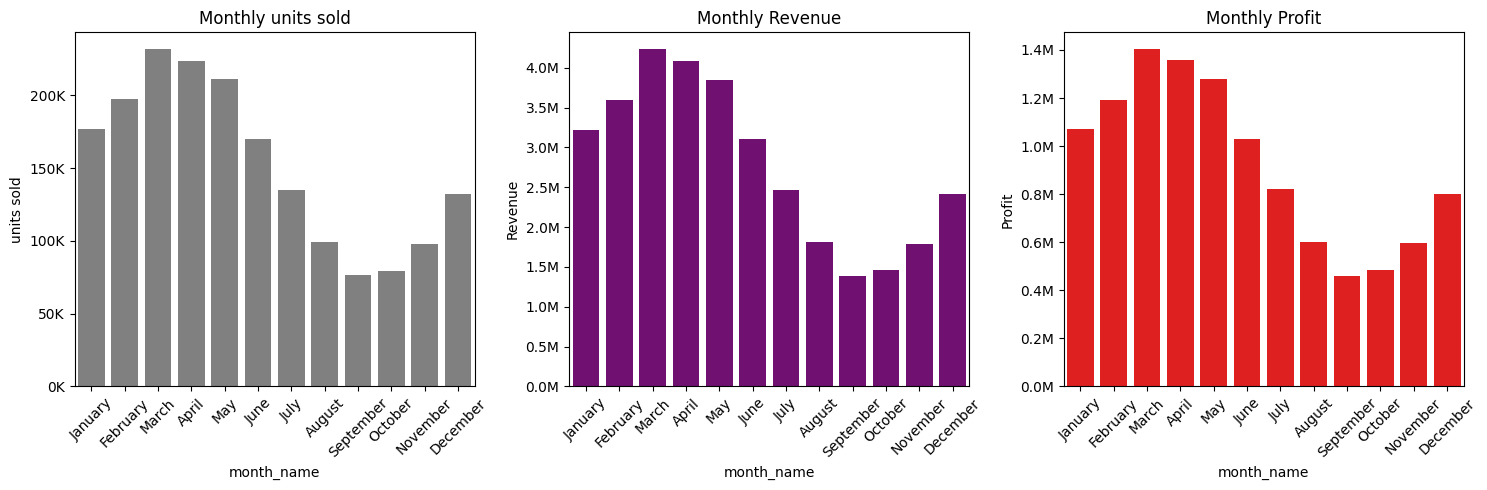

In [102]:
fig, axes= plt.subplots(1,3, figsize=(15,5))
sns.barplot(x='month_name', y='units_sold', data=monthly_sales, ax=axes[0], color='grey')
axes[0].set_title('Monthly units sold')
axes[0].set_ylabel('units sold')
axes[0].yaxis.set_major_formatter(FuncFormatter(thousands_formatter))

sns.barplot(x='month_name', y='revenue', data= monthly_sales, ax=axes[1], color='purple')
axes[1].set_title('Monthly Revenue')
axes[1].set_ylabel('Revenue')
axes[1].yaxis.set_major_formatter(FuncFormatter(millions_formatter))

sns.barplot(x='month_name', y='profit', data= monthly_sales, ax=axes[2], color='red')
axes[2].set_title('Monthly Profit')
axes[2].set_ylabel('Profit')
axes[2].yaxis.set_major_formatter(FuncFormatter(millions_formatter))

for ax in axes:
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

- demand increases from january and peaks around march-april then declines steadily until sep-oct and recovers towards end of year. 
- the trend remains similar across revenue, profit, units sold. 
- hence, there is seasonal demand rather than steady demand throughout year. 
- inventory planning can be optimised to serve for seasonal demands instead of using fixed reorder quantities throughout year. 

In [ ]:
#products (SKUs) that generate most revenue:

#top SKUs by revenue & profit:
top_sku= df.groupby('sku_id')[['revenue', 'profit']].sum().reset_index()
#top_sku.head(3)
top_sku_revenue= top_sku.sort_values(by='revenue', ascending=False).head(10)
top_sku_profit= top_sku.sort_values(by='profit', ascending=False).head(10)


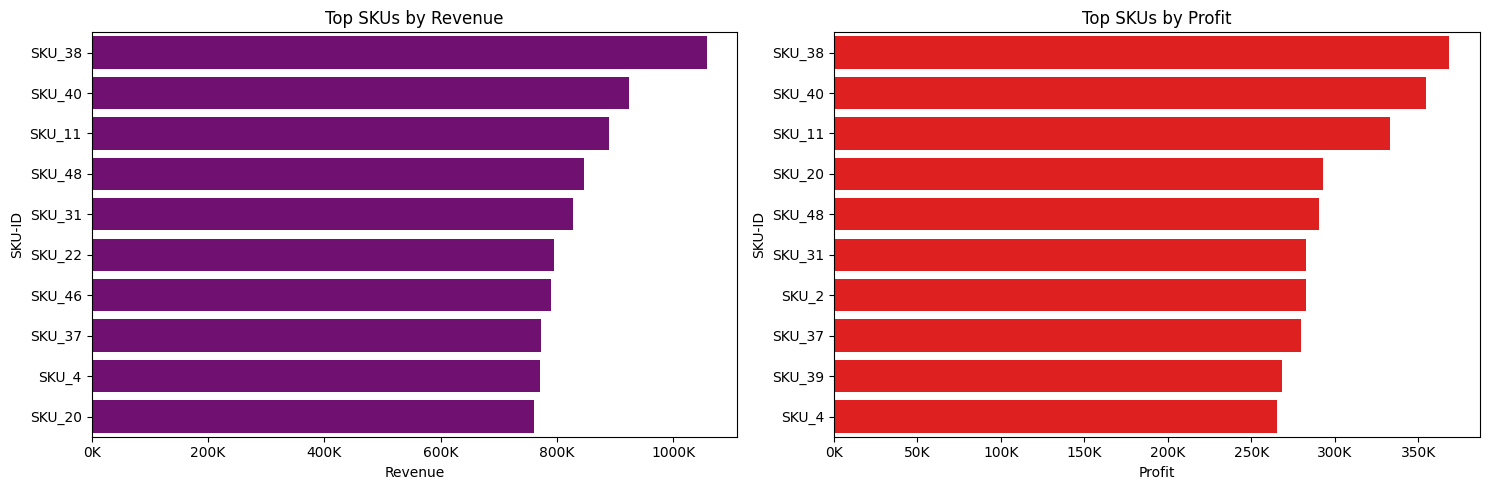

In [104]:
#plotting:

fig, axes= plt.subplots(1,2, figsize=(15,5))
sns.barplot(x='revenue', y='sku_id', data=top_sku_revenue, ax=axes[0], color='purple')
axes[0].set_title('Top SKUs by Revenue')
axes[0].set_xlabel('Revenue')
axes[0].set_ylabel('SKU-ID')
axes[0].xaxis.set_major_formatter(FuncFormatter(thousands_formatter))

sns.barplot(x='profit', y='sku_id', data= top_sku_profit, ax=axes[1], color='red')
axes[1].set_title('Top SKUs by Profit')
axes[1].set_xlabel('Profit')
axes[1].set_ylabel('SKU-ID')
axes[1].xaxis.set_major_formatter(FuncFormatter(thousands_formatter))

plt.tight_layout()
plt.show()

- SKU_38 is the top performer in both revenue and profit.
- these high performing SKUs should have closer inventory monitoring.
- forecast accuracy is important for these products since they have higher financial impact.


In [40]:
#best performing region: compared by revenue, profit, units sold

top_region= df.groupby('region')[['revenue', 'profit', 'units_sold']].sum().reset_index()
top_region

,region,revenue,profit,units_sold
0,East,8398382.40,2789524.01,459961
1,North,8411171.01,2788397.27,459849
2,South,8320450.82,2762288.19,456954
3,West,8296332.99,2747991.76,453215


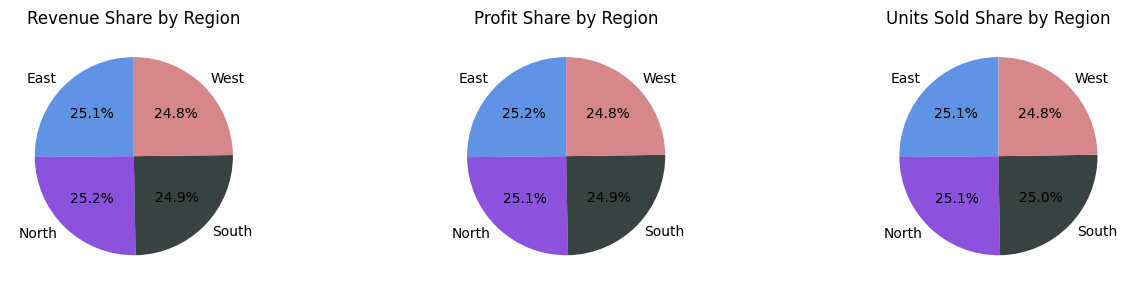

In [81]:
#plotting:
fig, axes = plt.subplots(1, 3, figsize=(14, 3))
colors = ["#6093E3", "#8A52DD", "#384241", "#D6878A"]

axes[0].pie(top_region["revenue"],labels=top_region["region"],
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,)
axes[0].set_title("Revenue Share by Region")

axes[1].pie(top_region["profit"],labels=top_region["region"],
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,)
axes[1].set_title("Profit Share by Region")

axes[2].pie(top_region["units_sold"],labels=top_region["region"],
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,)
axes[2].set_title("Units Sold Share by Region")

plt.tight_layout()
plt.show()


#### - *quarter, almost equal distribution for each region*
- no region appears to be significantly underperforming.
- regional demand is fairly balanced, so optimisation efforts should focus more on SKU and warehouse levels than on geographical regions.

In [42]:
#warehouse performance:
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
top_warehouse= df.groupby('warehouse_id')[['revenue', 'profit', 'inventory_value']].sum().reset_index()
top_warehouse

,warehouse_id,revenue,profit,inventory_value
0,WH_1,"6,269,758.79","2,009,776.17","98,662,156.36"
1,WH_2,"7,395,653.40","2,405,372.73","121,398,875.91"
2,WH_3,"6,478,245.81","2,193,922.67","97,151,661.10"
3,WH_4,"6,346,286.39","2,078,071.72","101,103,440.78"
4,WH_5,"6,936,392.83","2,401,057.94","106,927,856.97"


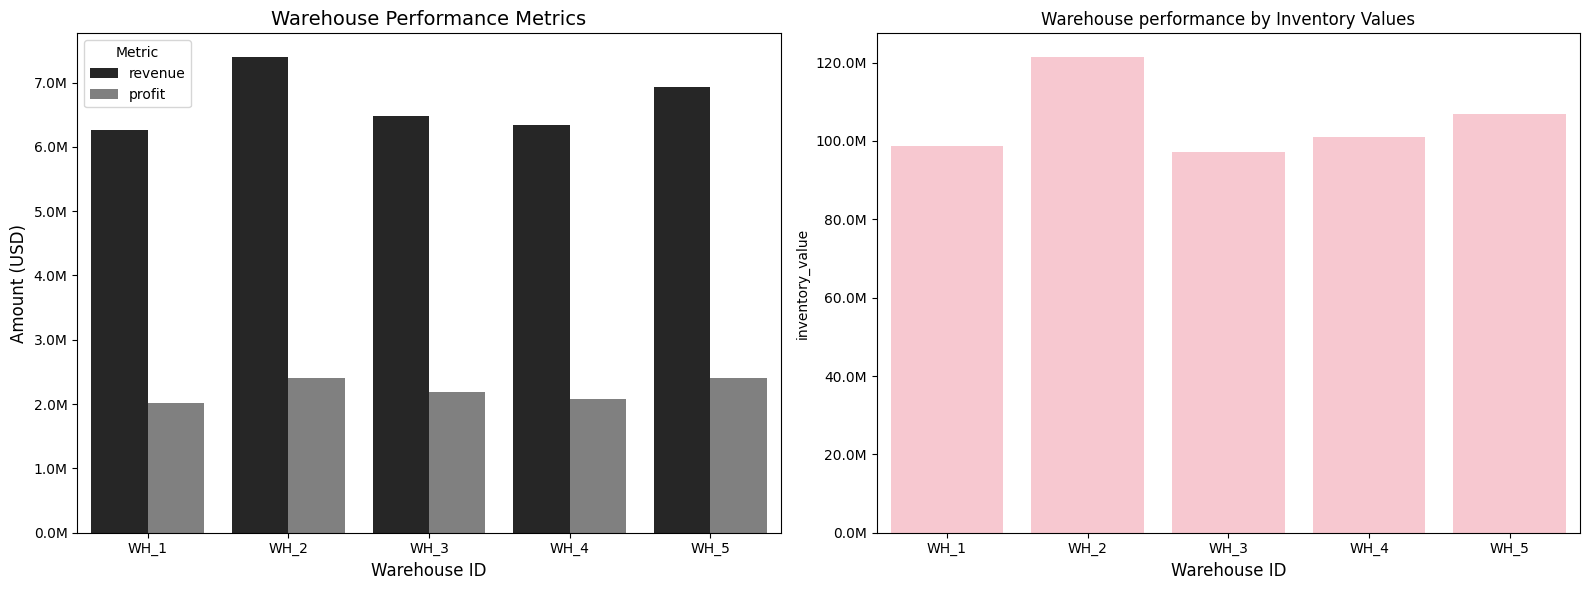

In [108]:
df_long = top_warehouse.melt(
    id_vars="warehouse_id",
    value_vars=["revenue", "profit"],
    var_name="Metric",
    value_name="Amount",
)
fig,axes= plt.subplots(1,2,figsize=(16,6))
sns.barplot(data=df_long, x="warehouse_id", y="Amount", hue="Metric", ax=axes[0], palette='dark:grey')
axes[0].set_title("Warehouse Performance Metrics", fontsize=14)
axes[0].set_xlabel("Warehouse ID", fontsize=12)
axes[0].set_ylabel("Amount (USD)", fontsize=12)
axes[0].yaxis.set_major_formatter(FuncFormatter(millions_formatter)) 

sns.barplot(x='warehouse_id', y='inventory_value', data=top_warehouse, ax=axes[1], color='pink')
axes[1].set_title('Warehouse performance by Inventory Values')
axes[1].set_xlabel("Warehouse ID", fontsize=12)
axes[1].yaxis.set_major_formatter(FuncFormatter(millions_formatter)) 
plt.tight_layout()

#### - *warehouse 2 has maximum profits, revenue, inventory value as compared to rest*
- warehouse 5 is behind in revenue and profit as compared to rest. 
- so WH_2 has most capital in inventory and inventory optimisation here could be financially beneficial. 

#

### Inventory analysis

Text(0.5, 0, 'Inventory-levels')

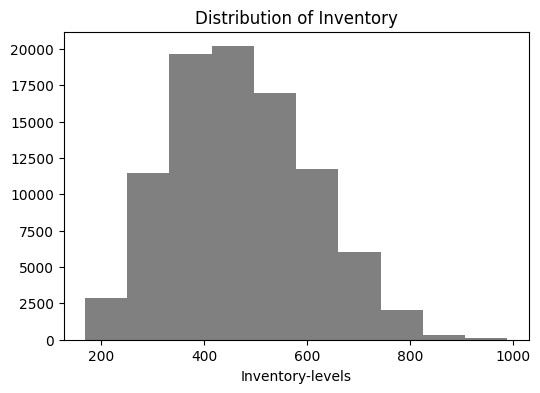

In [ ]:
#Inventory Distribution
plt.figure(figsize=(6,4))
plt.hist(df['inventory_level'], color='grey')
plt.title('Distribution of Inventory')
plt.xlabel('Inventory-levels')

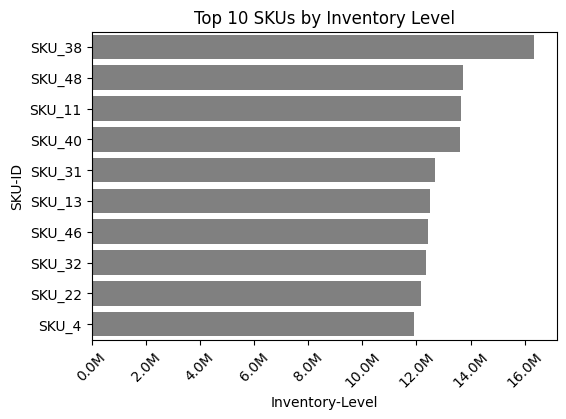

In [110]:
#SKUs that hold most inventory:
top10_sku_by_inventory= df.groupby('sku_id')[['inventory_value']].sum().sort_values(by='inventory_value',ascending=False).reset_index().head(10)
plt.figure(figsize=(6,4))
sns.barplot(x='inventory_value', y='sku_id', data=top10_sku_by_inventory, color='grey')
plt.title('Top 10 SKUs by Inventory Level')
plt.xlabel('Inventory-Level')
plt.ylabel('SKU-ID')
plt.gca().xaxis.set_major_formatter(FuncFormatter(millions_formatter))
plt.tick_params(axis='x', rotation=45)

In [112]:
#reorder required:
reorder= (df['reorder_needed'].value_counts().reset_index())
reorder.columns= ['reorder-needed','count']
reorder

,reorder-needed,count
0,0,86209
1,1,5041


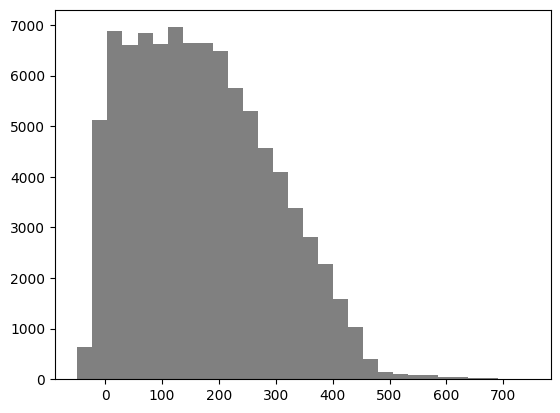

In [120]:
#plotting inventory distribution to see how much buffer exists safely above teh reorder point
plt.hist(df['inventory_difference'], bins=30, color='grey')
plt.show()

- inventory levels appear approximately bell shaped with most observations concentrated in the mid range.
- only **5,041 out of 91,250 (~5.5%)** records require reordering.
- they generally maintain inventory above reorder thresholds.
- immediate stockout risk appears relatively low.

**however, maintaining high inventory also increases carrying costs, making inventory optimization worthwhile for this case.**

### Supplier analysis

In [122]:
#average lead time:
supplier= df.groupby('supplier_id')['supplier_lead_time_days'].mean().sort_values().reset_index()

#average order quantity:
orders= df.groupby('supplier_id')['order_quantity'].mean().sort_values(ascending=False).reset_index()

print(supplier.head(3))
print(orders.head())


  supplier_id  supplier_lead_time_days
0       SUP_5                     6.96
1      SUP_10                     7.41
2       SUP_7                     7.56
  supplier_id  order_quantity
0       SUP_2           19.46
1       SUP_6           19.36
2       SUP_4           19.35
3       SUP_5           19.34
4       SUP_7           19.28


- average order quantity is almost similar for all

Text(0, 0.5, 'Lead Time (days)')

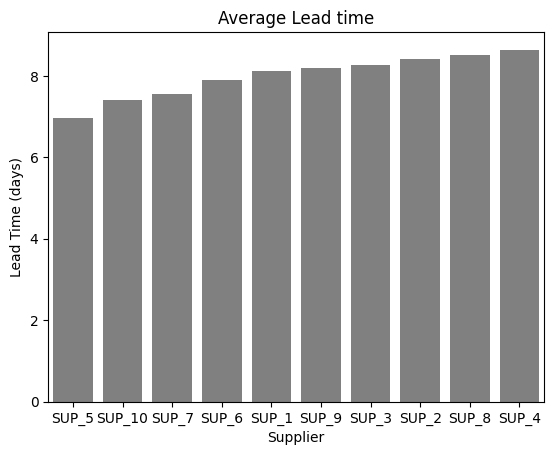

In [123]:
#plots:

sns.barplot(x='supplier_id', y='supplier_lead_time_days', data=supplier, color='grey')
plt.title('Average Lead time')
plt.xlabel('Supplier')
plt.ylabel('Lead Time (days)')


- supplier lead times vary across suppliers.
- average order quantities are relatively similar between suppliers.

#

### Promotional analysis

goal is to identify if promotions increased sales

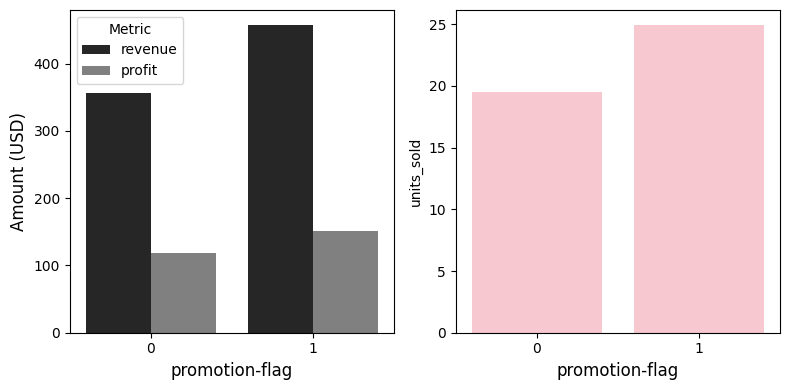

In [129]:
promoted= df.groupby('promotion_flag')[['units_sold','revenue','profit']].mean().reset_index()
df_promo = promoted.melt(
    id_vars="promotion_flag",
    value_vars=["revenue", "profit"],
    var_name="Metric",
    value_name="Amount",
)
fig,axes= plt.subplots(1,2,figsize=(8,4))

sns.barplot(data=df_promo, x="promotion_flag", y="Amount", hue="Metric", ax=axes[0], palette='dark:grey')
axes[0].set_xlabel("promotion-flag", fontsize=12)
axes[0].set_ylabel("Amount (USD)", fontsize=12)

sns.barplot(x='promotion_flag', y='units_sold', data=promoted, ax=axes[1], color='pink')
axes[1].set_xlabel("promotion-flag", fontsize=12)
plt.tight_layout()

- promotional campaigns are associated with higher average sales and revenue, suggesting promotions positively influence demand.

#

#### Correlation:


In [130]:
cols= df[['units_sold','inventory_level','supplier_lead_time_days', 'reorder_point','order_quantity','unit_cost','unit_price','revenue','profit','inventory_value']]
cols.corr()

,units_sold,inventory_level,supplier_lead_time_days,reorder_point,order_quantity,unit_cost,unit_price,revenue,profit,inventory_value
units_sold,1.00,-0.06,0.00,-0.00,0.07,0.00,0.00,0.73,0.62,-0.04
inventory_level,-0.06,1.00,0.01,0.40,0.29,0.00,-0.00,-0.05,-0.05,0.59
supplier_lead_time_days,0.00,0.01,1.00,0.03,-0.00,0.07,0.07,0.05,0.04,0.06
reorder_point,-0.00,0.40,0.03,1.00,0.00,0.00,-0.02,-0.01,-0.03,0.23
order_quantity,0.07,0.29,-0.00,0.00,1.00,0.00,0.00,0.05,0.04,0.17
unit_cost,0.00,0.00,0.07,0.00,0.00,1.00,0.95,0.59,0.49,0.78
unit_price,0.00,-0.00,0.07,-0.02,0.00,0.95,1.00,0.63,0.63,0.73
revenue,0.73,-0.05,0.05,-0.01,0.05,0.59,0.63,1.00,0.93,0.43
profit,0.62,-0.05,0.04,-0.03,0.04,0.49,0.63,0.93,1.00,0.35
inventory_value,-0.04,0.59,0.06,0.23,0.17,0.78,0.73,0.43,0.35,1.00


- most operational variables appear to be largely independent.
- inventory levels alone are **not** good predictors of demand.
- this reinforces the need for dedicated demand forecasting rather than assuming higher inventory will naturally lead to higher sales.
- as per corr, revenue closely follows units sold throughout year.
- sales volumne is primary driver of revenue. 
- hence improving demand forecasting would be a much better approach than pricing optimisation. 

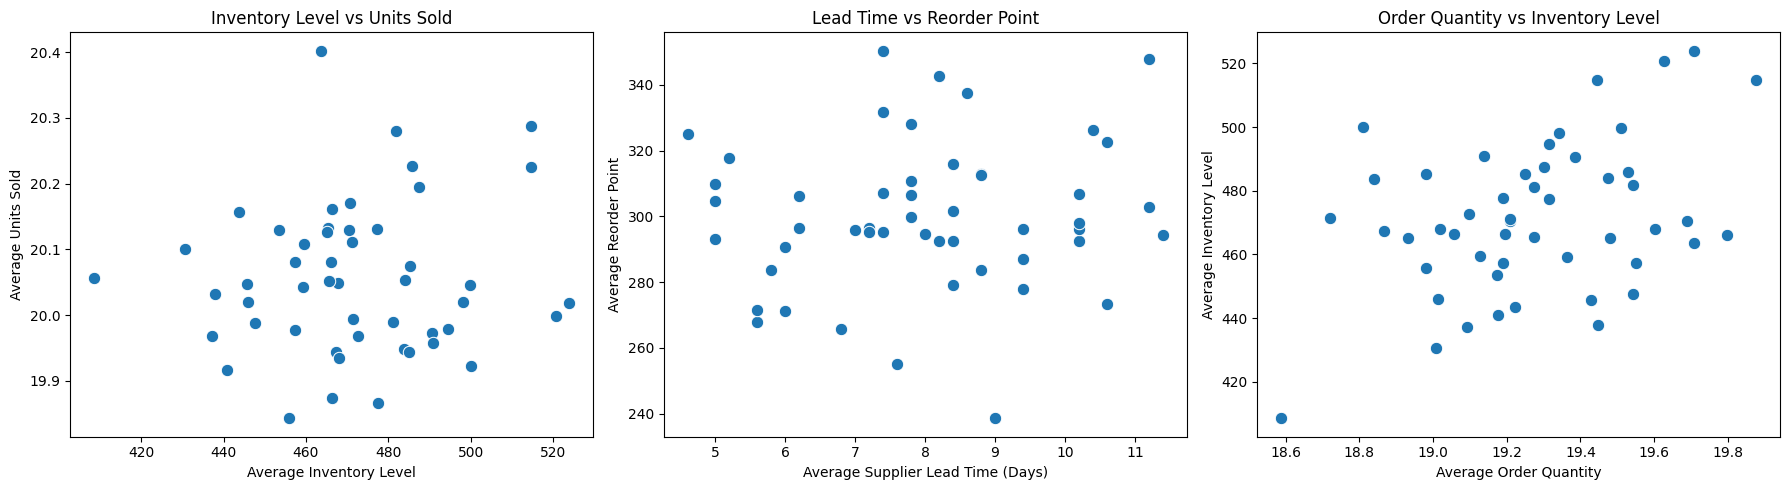

In [132]:
sku_df= (df.groupby('sku_id')
      .agg({
          'inventory_level': 'mean',
          'units_sold': 'mean',
          'order_quantity': 'mean',
          'reorder_point': 'mean',
          'supplier_lead_time_days': 'mean'
      }).reset_index())
plt.figure(figsize=(18,5))
plt.subplot(1,3,1)
sns.scatterplot(data=sku_df,x='inventory_level',y='units_sold',s=80)
plt.title('Inventory Level vs Units Sold')
plt.xlabel('Average Inventory Level')
plt.ylabel('Average Units Sold')

plt.subplot(1,3,2)
sns.scatterplot(data=sku_df,x='supplier_lead_time_days',y='reorder_point',s=80)
plt.title('Lead Time vs Reorder Point')
plt.xlabel('Average Supplier Lead Time (Days)')
plt.ylabel('Average Reorder Point')

plt.subplot(1,3,3)
sns.scatterplot(data=sku_df,x='order_quantity', y='inventory_level',s=80)
plt.title('Order Quantity vs Inventory Level')
plt.xlabel('Average Order Quantity')
plt.ylabel('Average Inventory Level')

plt.tight_layout()
plt.show()

### OVERALL SUMMARY/ BUSINESS CONCLUSIONS:

the EDA suggests a supply chain characterized by:

- strong seasonal demand.
- revenue driven primarily by sales volume.
- a small number of high-value SKUs contributing disproportionately to business performance.
- balanced regional performance.
- one warehouse (WH_2) carrying the highest inventory and generating the highest revenue.
- generally healthy inventory levels with relatively few immediate replenishment needs.
- weak direct relationships between inventory and demand, indicating that inventory decisions should rely on forecasting rather than current stock levels alone.